<a href="https://colab.research.google.com/github/ksenia-andreeva/kan-physics-recovery/blob/main/kan_vs_mlp_sp1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практика: Восстановление физического закона из данных**

Задача: сгенерировать данные затухающего гармонического осциллятора и восстановить закон движения.

# **Часть 1. Генерация данных с шумом**

Установка библиотек + проверка устройства

In [ ]:
!pip install git+https://github.com/KindXiaoming/pykan.git

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.integrate import solve_ivp
from kan import KAN
from kan.utils import ex_round

torch.set_default_dtype(torch.float32)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Работает на устройстве: {device}")

Traceback (most recent call last):
  File "<frozen importlib._bootstrap>", line 1331, in _find_and_load_unlocked
  File "<frozen importlib._bootstrap>", line 935, in _load_unlocked
  File "<frozen importlib._bootstrap_external>", line 999, in exec_module
  File "<frozen importlib._bootstrap>", line 488, in _call_with_frames_removed
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/main.py", line 11, in <module>
    from pip._internal.cli.autocompletion import autocomplete
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/autocompletion.py", line 10, in <module>
    from pip._internal.cli.main_parser import create_main_parser
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/main_parser.py", line 9, in <module>
    from pip._internal.build_env import get_runnable_pip
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/build_env.py", line 19, in <module>
    from pip._internal.cli.spinners import open_spinner
  File "/usr/local/li

Генерация траекторий численным интегрированием: координата *x(t)*, скорость *v(t)* и ускорение *a(t)*

In [ ]:
k, m, c = 4.0, 1.0, 0.3
noise_level = 0.01  # гауссов шум - % от стандартного отклонения a

def rhs(t, y):
    x, v = y
    a = -(k/m)*x - (c/m)*v
    return [v, a]

all_data = []

for x0 in [1.0, 0.5, 2.0]:
    for v0 in [0.0, 0.5, -0.5]:
        sol = solve_ivp(rhs, (0, 20), y0=[x0, v0], t_eval=np.linspace(0, 20, 500))
        x, v = sol.y
        a_clean = -(k/m)*x - (c/m)*v # истинное ускорение

        # с шумом
        a_std = np.std(a_clean) # амплитуда сигнала для этой траектории
        noise = np.random.normal(0, noise_level * a_std, size=len(a_clean))
        a_noisy = a_clean + noise

        for i in range(len(x)):
            all_data.append([x[i], v[i], a_noisy[i]])   # сохранение зашумлённого a

all_data = np.array(all_data)

Формирование датасета из полученных данных (входы: *x*,*v*, выход: *a*)

In [ ]:
X = all_data[:, :2]   # (x, v)
y = all_data[:, 2]    # a

# pазбиение на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_raw = X_train.astype(np.float32)
X_test_raw  = X_test.astype(np.float32)
y_train_raw = y_train.astype(np.float32).reshape(-1, 1)
y_test_raw  = y_test.astype(np.float32).reshape(-1, 1)

# тензоры
X_train_t = torch.tensor(X_train_raw, dtype=torch.float32)
y_train_t = torch.tensor(y_train_raw, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_raw, dtype=torch.float32)
y_test_t  = torch.tensor(y_test_raw, dtype=torch.float32)

dataset = {
    'train_input': X_train_t,
    'train_label': y_train_t,
    'test_input': X_test_t,
    'test_label': y_test_t
}

# **Часть 2. Создание и обучение KAN [2,2,1] (66 параметров)**

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 7.20e-02 | test_loss: 7.56e-02 | reg: 0.00e+00 | :  28%|▎| 17/60 [00:05<00:13,  3.22it


KeyboardInterrupt: 

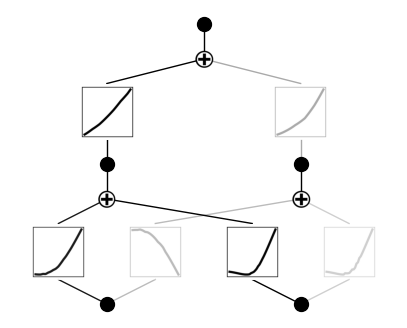

In [ ]:
model_kan = KAN(width=[2, 2, 1], grid=10, k=1, seed=42, device=device)

model_kan(dataset['train_input'])
model_kan.plot()

steps = 10
train_losses_kan = []
test_losses_kan = []

for step in range(steps):
    res = model_kan.fit(dataset, opt="LBFGS", steps=60, lamb=0.0)
    train_losses_kan.append(float(res['train_loss'][-1]))
    test_losses_kan.append(float(res['test_loss'][-1]))

model_kan.plot()

with torch.no_grad():
    pred_kan_scaled = model_kan(dataset['test_input'])
    mse_kan_scaled = nn.functional.mse_loss(pred_kan_scaled, dataset['test_label'])
print(f"MSE KAN: {mse_kan_scaled.item():.8f}")

Символьная регрессия

In [ ]:
model_kan = model_kan.prune()
model_kan.plot()

lib = ['x','x^2','x^3','x^4','exp','log','sqrt','tanh','sin','abs']
model_kan.auto_symbolic(lib=lib)

formula = ex_round(model_kan.symbolic_formula()[0][0],4)
print("Символьная формула KAN:", formula)
print(f"Реальная символьная формула: {-k/m} + {-c/m}")

# **Часть 3. Создание и обучение MLP [2,16,1] (65 параметров)**

In [ ]:
class MLP(nn.Module):
    def __init__(self): # конструктор
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 1))
    def forward(self, x): # описывает как данные проходят через сеть
        return self.net(x)

model_mlp = MLP()
criterion = nn.MSELoss()
optimizer = optim.Adam(model_mlp.parameters(), lr=0.001) # оптимизатор Ir=0.01 -> Ir=0.001

# обучение
epochs = 6000
train_losses_mlp = []
test_losses_mlp = []

for epoch in range(epochs):
    model_mlp.train()
    optimizer.zero_grad()
    pred = model_mlp(dataset['train_input'])
    loss = criterion(pred, dataset['train_label'])
    loss.backward()
    optimizer.step()

    if (epoch+1) % 500 == 0:
        model_mlp.eval()
        with torch.no_grad():
            test_loss = criterion(model_mlp(dataset['test_input']), dataset['test_label'])
        print(f"| train loss: {loss.item():.10f} | test loss: {test_loss.item():.10f} | MLP epoch {epoch+1}/{epochs}")

        train_losses_mlp.append(loss.item())
        test_losses_mlp.append(test_loss.item())

model_mlp.eval()
with torch.no_grad():
    pred_mlp_scaled = model_mlp(dataset['test_input'])
    mse_mlp_scaled = criterion(pred_mlp_scaled, dataset['test_label'])
print(f"MSE MLP: {mse_mlp_scaled.item():.12f}")

# **Часть 4. График MSE от шагов/эпох (при гауссовом шуме 3%)**

In [ ]:
import matplotlib.pyplot as plt

kan_steps = [i*60 for i in range(len(train_losses_kan))]
mlp_epochs = [i*600 for i in range(len(train_losses_mlp))]

fig, ax1 = plt.subplots(figsize=(12, 6))

# Ось X для KAN (нижняя)
ax1.plot(kan_steps, train_losses_kan, label='KAN Train', color='blue', linestyle='-')
ax1.plot(kan_steps, test_losses_kan,  label='KAN Test',  color='blue', linestyle='--')
ax1.set_xlabel('Steps (KAN)')
ax1.set_ylabel('MSE Loss')
ax1.set_yscale('log')
ax1.legend(loc='upper left')
ax1.grid(True, which='both', linestyle=':', alpha=0.5)

# Ось X для MLP (верхняя)
ax2 = ax1.twiny()
ax2.plot(mlp_epochs, train_losses_mlp, label='MLP Train', color='orange', linestyle='-')
ax2.plot(mlp_epochs, test_losses_mlp,  label='MLP Test',  color='orange', linestyle='--')
ax2.set_xlabel('Epochs (MLP)')
ax2.legend(loc='upper right')
ax2.set_xlim(mlp_epochs[0], mlp_epochs[-1])   # чтобы шкала использовала всё пространство

plt.title('Сравнение обучения KAN и MLP (логирование с интервалом)')
plt.show()

print("Символьная формула KAN:", formula)
print(f"Реальная символьная формула: {-k/m} + {-c/m}")